# Task: Covid-19 Data Analysis
### This notebook is used to understand the comprehension of Data Analysis techniques using Pandas library.

### Data Source: 
https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_daily_reports

### File naming convention

MM-DD-YYYY.csv in UTC.

### Field description

- Province_State: China - province name; US/Canada/Australia/ - city name, state/province name; Others - name of the event (e.g., "Diamond Princess" cruise ship); other countries - blank.

- Country_Region: country/region name conforming to WHO (will be updated).

- Last_Update: MM/DD/YYYY HH:mm (24 hour format, in UTC).

- Confirmed: the number of confirmed cases. For Hubei Province: from Feb 13 (GMT +8), we report both clinically diagnosed and lab-confirmed cases. For lab-confirmed cases only (Before Feb 17), please refer to who_covid_19_situation_reports. For Italy, diagnosis standard might be changed since Feb 27 to "slow the growth of new case numbers." (Source)

- Deaths: the number of deaths.

- Recovered: the number of recovered cases.

### Question 1

#### Read the dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/07-20-2021.csv')
df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-07-21 04:21:40,33.93911,67.709953,142414,6266,82586.0,53562.0,Afghanistan,365.836294,4.399848
1,NaN,NaN,NaN,Albania,2021-07-21 04:21:40,41.15330,20.168300,132740,2456,130086.0,198.0,Albania,4612.551254,1.850234
2,NaN,NaN,NaN,Algeria,2021-07-21 04:21:40,28.03390,1.659600,155784,3979,107041.0,44764.0,Algeria,355.257228,2.554178
3,NaN,NaN,NaN,Andorra,2021-07-21 04:21:40,42.50630,1.521800,14379,127,13930.0,322.0,Andorra,18609.978645,0.883232
4,NaN,NaN,NaN,Angola,2021-07-21 04:21:40,-11.20270,17.873900,41061,970,34857.0,5234.0,Angola,124.933564,2.362339


#### Display the top 5 rows in the data

In [41]:
df.head(5)

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-07-21 04:21:40,33.93911,67.709953,142414,6266,82586.0,53562.0,Afghanistan,365.836294,4.399848
1,NaN,NaN,NaN,Albania,2021-07-21 04:21:40,41.15330,20.168300,132740,2456,130086.0,198.0,Albania,4612.551254,1.850234
2,NaN,NaN,NaN,Algeria,2021-07-21 04:21:40,28.03390,1.659600,155784,3979,107041.0,44764.0,Algeria,355.257228,2.554178
3,NaN,NaN,NaN,Andorra,2021-07-21 04:21:40,42.50630,1.521800,14379,127,13930.0,322.0,Andorra,18609.978645,0.883232
4,NaN,NaN,NaN,Angola,2021-07-21 04:21:40,-11.20270,17.873900,41061,970,34857.0,5234.0,Angola,124.933564,2.362339


#### Show the information of the dataset

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4014 entries, 0 to 4013
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3266 non-null   float64
 1   Admin2               3271 non-null   str    
 2   Province_State       3835 non-null   str    
 3   Country_Region       4014 non-null   str    
 4   Last_Update          4014 non-null   str    
 5   Lat                  3924 non-null   float64
 6   Long_                3924 non-null   float64
 7   Confirmed            4014 non-null   int64  
 8   Deaths               4014 non-null   int64  
 9   Recovered            737 non-null    float64
 10  Active               737 non-null    float64
 11  Combined_Key         4014 non-null   str    
 12  Incident_Rate        3924 non-null   float64
 13  Case_Fatality_Ratio  3971 non-null   float64
dtypes: float64(7), int64(2), str(5)
memory usage: 439.2 KB


#### Show the sum of missing values of features in the dataset

In [43]:
df.isnull().sum()

FIPS                    748
Admin2                  743
Province_State          179
Country_Region            0
Last_Update               0
Lat                      90
Long_                    90
Confirmed                 0
Deaths                    0
Recovered              3277
Active                 3277
Combined_Key              0
Incident_Rate            90
Case_Fatality_Ratio      43
dtype: int64

### Question 2

#### Show the number of Confirmed cases by Country

In [44]:
df.groupby('Country_Region')['Confirmed'].sum().reset_index()

,Country_Region,Confirmed
0,Afghanistan,142414
1,Albania,132740
2,Algeria,155784
3,Andorra,14379
4,Angola,41061
...,...,...
196,West Bank and Gaza,315761
197,Winter Olympics 2022,0
198,Yemen,6992
199,Zambia,187602


#### Show the number of Deaths by Country

In [45]:
df.groupby('Country_Region')['Deaths'].sum().reset_index()

,Country_Region,Deaths
0,Afghanistan,6266
1,Albania,2456
2,Algeria,3979
3,Andorra,127
4,Angola,970
...,...,...
196,West Bank and Gaza,3589
197,Winter Olympics 2022,0
198,Yemen,1371
199,Zambia,3138


#### Show the number of Recovered cases by Country

In [46]:
df.groupby('Country_Region')['Recovered'].sum().reset_index()

,Country_Region,Recovered
0,Afghanistan,82586.0
1,Albania,130086.0
2,Algeria,107041.0
3,Andorra,13930.0
4,Angola,34857.0
...,...,...
196,West Bank and Gaza,310601.0
197,Winter Olympics 2022,0.0
198,Yemen,4162.0
199,Zambia,174728.0


#### Show the number of Active Cases by Country

In [47]:
df.groupby('Country_Region')['Active'].sum().reset_index()

,Country_Region,Active
0,Afghanistan,53562.0
1,Albania,198.0
2,Algeria,44764.0
3,Andorra,322.0
4,Angola,5234.0
...,...,...
196,West Bank and Gaza,1571.0
197,Winter Olympics 2022,0.0
198,Yemen,1459.0
199,Zambia,9736.0


#### Show the latest number of Confirmed, Deaths, Recovered and Active cases Country-wise

In [48]:
df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

,Country_Region,Confirmed,Deaths,Recovered,Active
0,Afghanistan,142414,6266,82586.0,53562.0
1,Albania,132740,2456,130086.0,198.0
2,Algeria,155784,3979,107041.0,44764.0
3,Andorra,14379,127,13930.0,322.0
4,Angola,41061,970,34857.0,5234.0
...,...,...,...,...,...
196,West Bank and Gaza,315761,3589,310601.0,1571.0
197,Winter Olympics 2022,0,0,0.0,0.0
198,Yemen,6992,1371,4162.0,1459.0
199,Zambia,187602,3138,174728.0,9736.0


### Question 3

### Show the countries with no recovered cases

In [49]:
recovered = df.groupby('Country_Region')['Recovered'].sum().reset_index()
recovered[recovered['Recovered'] == 0]

,Country_Region,Recovered
5,Antarctica,0.0
17,Belgium,0.0
92,Kiribati,0.0
93,"Korea, North",0.0
126,Nauru,0.0
137,Palau,0.0
157,Serbia,0.0
170,Summer Olympics 2020,0.0
172,Sweden,0.0
181,Tonga,0.0


#### Show the countries with no confirmed cases

In [50]:
сonfirmed = df.groupby('Country_Region')['Confirmed'].sum().reset_index()
сonfirmed[сonfirmed['Confirmed'] == 0]

,Country_Region,Confirmed
5,Antarctica,0
93,"Korea, North",0
126,Nauru,0
137,Palau,0
181,Tonga,0
185,Tuvalu,0
197,Winter Olympics 2022,0


#### Show the countries with no deaths

In [51]:
deaths = df.groupby('Country_Region')['Deaths'].sum().reset_index()
deaths[deaths['Deaths'] == 0]

,Country_Region,Deaths
5,Antarctica,0
51,Dominica,0
76,Holy See,0
92,Kiribati,0
93,"Korea, North",0
114,Marshall Islands,0
118,Micronesia,0
126,Nauru,0
137,Palau,0
152,Samoa,0


In [52]:
agg = df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
agg[agg['Deaths'] == 0]

,Country_Region,Confirmed,Deaths,Recovered
5,Antarctica,0,0,0.0
51,Dominica,206,0,195.0
76,Holy See,27,0,27.0
92,Kiribati,2,0,0.0
93,"Korea, North",0,0,0.0
114,Marshall Islands,4,0,4.0
118,Micronesia,1,0,1.0
126,Nauru,0,0,0.0
137,Palau,0,0,0.0
152,Samoa,3,0,3.0


### Question 4

#### Show the Top 10 countries with Confirmed cases

In [53]:
df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered']].sum().sort_values('Confirmed', ascending=False).head(10)

,Confirmed,Deaths,Recovered
Country_Region,,,
US,34298789,605568,0.0
India,31216337,418480,30390687.0
Brazil,19428736,544532,17371065.0
France,5952490,111707,409403.0
Russia,5931925,147457,5318062.0
Turkey,5546166,50650,5395300.0
United Kingdom,5542334,155939,16686.0
Argentina,4784219,102381,4420995.0
Colombia,4668750,117131,4422866.0


#### Show the Top 10 Countries with Active cases

In [54]:
df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().sort_values('Active', ascending=False).head(10)

,Confirmed,Deaths,Recovered,Active
Country_Region,,,,
France,5952490,111707,409403.0,5431380.0
United Kingdom,5542334,155939,16686.0,5396840.0
Spain,4189136,81148,150376.0,3957612.0
Mexico,2678297,236810,2104298.0,2441487.0
Peru,2096013,195332,2061951.0,1898679.0
Netherlands,1842653,18069,27563.0,1797021.0
Brazil,19428736,544532,17371065.0,1504192.0
Belgium,1108675,25213,0.0,1087118.0
Sweden,1095279,14650,0.0,1080629.0


### Question 5

#### Plot Country-wise Total deaths, confirmed, recovered and active casaes where total deaths have exceeded 50,000

In [55]:
import matplotlib.pyplot as plt

In [56]:
agg = df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().sort_values('Recovered', ascending=False).reset_index()
agg1 = agg[agg['Deaths'] > 50000]
print(agg1)

     Country_Region  Confirmed  Deaths   Recovered     Active
0             India   31216337  418480  30390687.0   407170.0
1            Brazil   19428736  544532  17371065.0  1504192.0
2            Turkey    5546166   50650   5395300.0   100216.0
3            Russia    5931925  147457   5318062.0   466406.0
4          Colombia    4668750  117131   4422866.0   128753.0
5         Argentina    4784219  102381   4420995.0   260843.0
6             Italy    4293083  127884   4115889.0    49310.0
7           Germany    3752420   91397   3640270.0    23153.0
8              Iran    3576148   87624   3168834.0   319690.0
9            Poland    2881594   75219   2652994.0   153381.0
10        Indonesia    2950058   76200   2323666.0   550192.0
11          Ukraine    2319886   55221   2246076.0    18589.0
12           Mexico    2678297  236810   2104298.0  2441487.0
13     South Africa    2311232   67676   2085119.0   158437.0
14             Peru    2096013  195332   2061951.0  1898679.0
39      

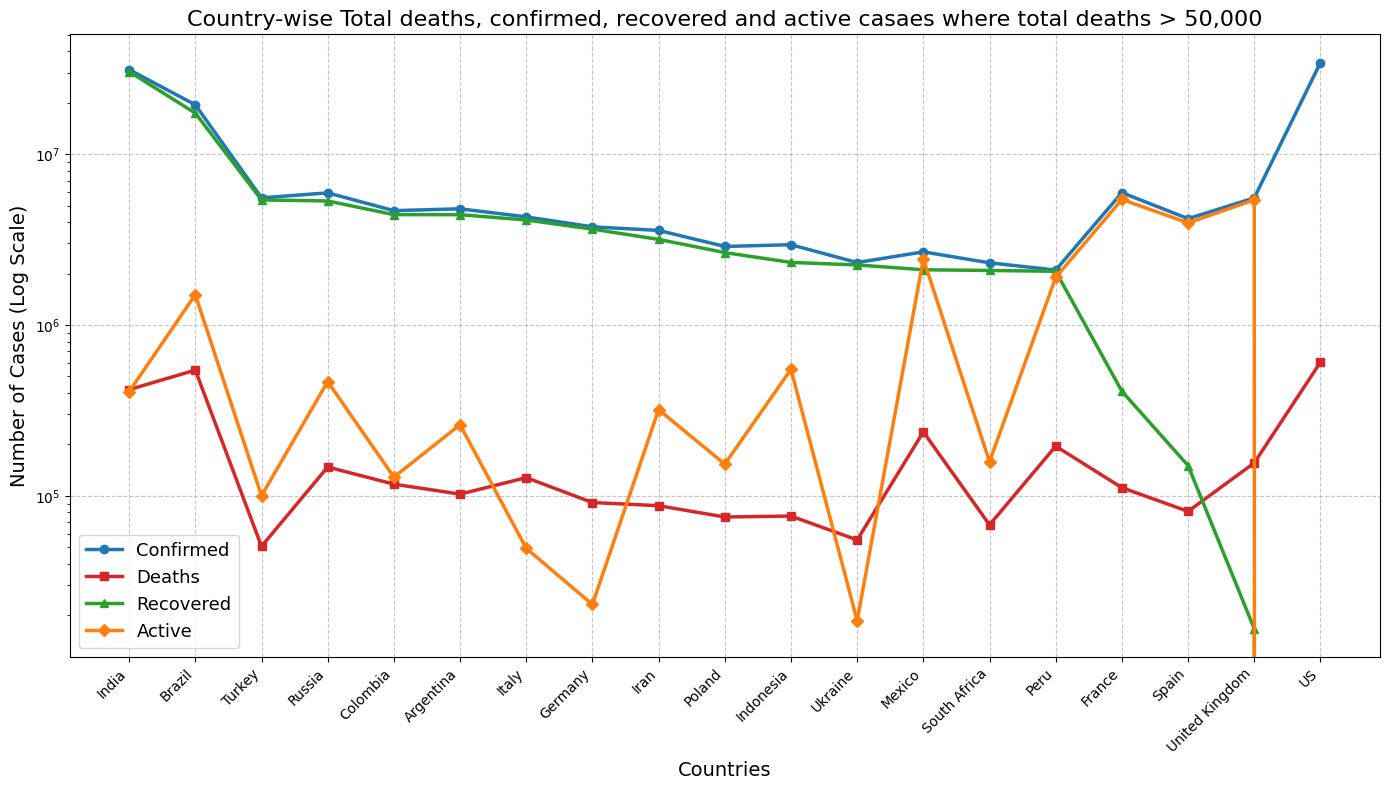

In [57]:
plt.figure(figsize=(14, 8))

plt.plot(agg1['Country_Region'], agg1['Confirmed'], marker='o', linewidth=2.5, label='Confirmed', color='#1f77b4')
plt.plot(agg1['Country_Region'], agg1['Deaths'],    marker='s', linewidth=2.5, label='Deaths',    color='#d62728')
plt.plot(agg1['Country_Region'], agg1['Recovered'], marker='^', linewidth=2.5, label='Recovered', color='#2ca02c')
plt.plot(agg1['Country_Region'], agg1['Active'],    marker='D', linewidth=2.5, label='Active',     color='#ff7f0e')

plt.yscale('log')                    
plt.title('Country-wise Total deaths, confirmed, recovered and active casaes where total deaths > 50,000', fontsize=16)
plt.xlabel('Countries', fontsize=14)
plt.ylabel('Number of Cases (Log Scale)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

### Question 6

### Plot Province/State wise Deaths in USA

In [58]:
import plotly.express as px

In [59]:
covid_data= pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/01-09-2021.csv')

In [60]:
covid_data.columns

Index(['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update',
       'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio'],
      dtype='str')

In [61]:
death = covid_data[covid_data['Country_Region'] == 'US'].groupby('Province_State')['Deaths'].sum().sort_values(ascending=False).reset_index()
death.head()

,Province_State,Deaths
0,New York,39288
1,Texas,30441
2,California,29638
3,Florida,22804
4,New Jersey,19854


In [62]:

fig = px.bar(
    death, 
    x='Province_State', 
    y='Deaths',
    title='COVID-19 Deaths by State',
    labels={'Deaths': 'Number of Deaths', 'Province_State': 'Province_State'},
    color='Deaths',                    
    color_continuous_scale='Reds',     
    text='Deaths'                      
)

# Customize layout
fig.update_layout(
    xaxis_title="State",
    yaxis_title="Number of Deaths",
    title_font_size=20,
    height=650,
    template="plotly_white",           
    xaxis_tickangle=-45
)

# Format the text on bars
fig.update_traces(
    texttemplate='%{text:,}',
    textposition='inside'
)

fig.show()

### Question 7

### Plot Province/State Wise Active Cases in USA

In [63]:
active = covid_data[covid_data['Country_Region'] == 'US'].groupby('Province_State')['Active'].sum().sort_values(ascending=False).reset_index()
active.head()

,Province_State,Active
0,California,2750669
1,Texas,1921602
2,Florida,1441893
3,New York,1080226
4,Illinois,1006442


In [64]:
fig = px.bar(
    active, 
    x='Province_State', 
    y='Active',
    title='COVID-19 Active cases by State',
    labels={'Active': 'Number of Active cases', 'Province_State': 'Province_State'},
    color='Active',                    
    color_continuous_scale='Reds',     
    text='Active'                      
)

# Customize layout
fig.update_layout(
    xaxis_title="State",
    yaxis_title="Number of Active cases",
    title_font_size=20,
    height=650,
    template="plotly_white",           
    xaxis_tickangle=-45
)

# Format the text on bars
fig.update_traces(
    texttemplate='%{text:,}',
    textposition='inside'
)

fig.show()

### Question 8

### Plot Province/State Wise Confirmed cases in USA

In [85]:
confirmed = covid_data[covid_data['Country_Region'] == 'US'].groupby('Province_State')['Confirmed'].sum().sort_values(ascending=False).reset_index()
confirmed.head()

,Province_State,Confirmed
0,California,2776975
1,Texas,1988676
2,Florida,1464697
3,New York,1119284
4,Illinois,1024039


In [ ]:
fig = px.bar(
    confirmed, 
    x='Province_State', 
    y='Confirmed',
    title='COVID-19 Confirmed cases by State',
    labels={'Confirmed': 'Number of Confirmed cases', 'Province_State': 'Province_State'},
    color='Confirmed',                    
    color_continuous_scale='Reds',     
    text='Confirmed'                      
)

# Customize layout
fig.update_layout(
    xaxis_title="State",
    yaxis_title="Number of Confirmed cases",
    title_font_size=20,
    height=650,
    template="plotly_white",           
    xaxis_tickangle=-45
)

# Format the text on bars
fig.update_traces(
    texttemplate='%{text:,}',
    textposition='inside'
)

fig.show()

### Question 9

### Plot Worldwide Confirmed Cases over time

In [67]:
import plotly.express as px
import plotly.io as pio

In [74]:
from datetime import date, timedelta

BASE_URL = (
    "https://raw.githubusercontent.com/CSSEGISandData/"
    "COVID-19/master/csse_covid_19_data/"
    "csse_covid_19_daily_reports/{}.csv"
)

# Generating all dates for 3 months (June, July, August) 2021
start = date(2021, 6, 1)
end   = date(2021, 8, 31)

covid_files = [
    BASE_URL.format(d.strftime("%m-%d-%Y"))
    for d in (start + timedelta(days=i) for i in range((end - start).days + 1))
]

covid_data_3months = pd.concat(
    (pd.read_csv(f) for f in covid_files),
    ignore_index=True
)

print(f"Total datafreim is: {covid_data_3months.shape}")

Total datafreim is: (369288, 14)


In [75]:
covid_data_3months['Last_Update'] = pd.to_datetime(covid_data_3months['Last_Update']).dt.to_period('M')

In [76]:
covid_data_3months.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-06,33.93911,67.709953,72977,2973,57741.0,12263.0,Afghanistan,187.464963,4.073886
1,NaN,NaN,NaN,Albania,2021-06,41.15330,20.168300,132337,2451,129473.0,413.0,Albania,4598.547502,1.852090
2,NaN,NaN,NaN,Algeria,2021-06,28.03390,1.659600,129218,3480,90057.0,35681.0,Algeria,294.674861,2.693123
3,NaN,NaN,NaN,Andorra,2021-06,42.50630,1.521800,13729,127,13479.0,123.0,Andorra,17768.718048,0.925049
4,NaN,NaN,NaN,Angola,2021-06,-11.20270,17.873900,34752,772,28190.0,5790.0,Angola,105.737591,2.221455


In [87]:
confirmed = covid_data_3months.groupby('Last_Update')['Confirmed'].sum().sort_values(ascending=False).reset_index()
confirmed = confirmed[confirmed['Last_Update'].astype(str).isin(['2021-06', '2021-07', '2021-08'])]
confirmed.head()

,Last_Update,Confirmed
0,2021-08,6446809717
1,2021-07,5880524963
2,2021-06,5137589245


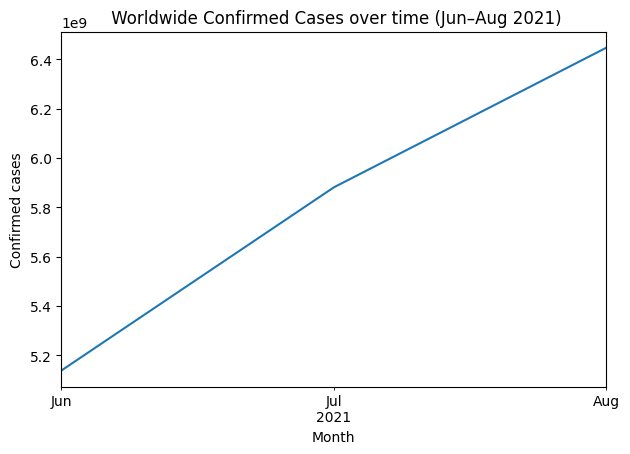

In [92]:
import matplotlib.pyplot as plt

confirmed.plot(kind='line', x='Last_Update', y='Confirmed', legend=False)
plt.title(' Worldwide Confirmed Cases over time (Jun–Aug 2021)')
plt.xlabel('Month')
plt.ylabel('Confirmed cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()